# Part 1b: Regularization Techniques in PyTorch

This notebook demonstrates the same regularization techniques as Part 1a, but implemented in PyTorch. We'll compare models with and without regularization through A/B testing.

## Topics Covered:
1. L1 Regularization (Lasso)
2. L2 Regularization (Ridge/Weight Decay)
3. Dropout
4. Early Stopping
5. Batch Normalization

**Author:** Advanced Deep Learning Course Assignment

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Check PyTorch version and GPU
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
Using device: cuda


In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Load and Prepare Data

We'll use MNIST dataset with a smaller subset to demonstrate overfitting.

In [3]:
from torchvision import datasets, transforms

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load MNIST
train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use a smaller subset for training (to demonstrate overfitting)
train_size = 4000
val_size = 1000
indices = torch.randperm(len(train_dataset_full))[:train_size + val_size]
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create subset datasets
train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices)
val_dataset = torch.utils.data.Subset(train_dataset_full, val_indices)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.82MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.33MB/s]

Training set size: 4000
Validation set size: 1000
Test set size: 10000


## Helper Functions

In [4]:
def train_epoch(model, train_loader, optimizer, criterion, device, l1_lambda=0):
    """
    Train model for one epoch.

    Args:
        l1_lambda: L1 regularization strength (added manually since PyTorch optimizer
                   only supports L2 via weight_decay)
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        data = data.view(data.size(0), -1)  # Flatten

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        # Add L1 regularization manually
        if l1_lambda > 0:
            l1_reg = torch.tensor(0., requires_grad=True).to(device)
            for param in model.parameters():
                l1_reg = l1_reg + torch.norm(param, 1)
            loss = loss + l1_lambda * l1_reg

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    return total_loss / len(train_loader), correct / total


def evaluate(model, data_loader, criterion, device):
    """
    Evaluate model on a dataset.
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            data = data.view(data.size(0), -1)
            output = model(data)
            total_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    return total_loss / len(data_loader), correct / total


def train_model(model, train_loader, val_loader, optimizer, criterion, device,
                epochs=50, l1_lambda=0, early_stopping=False, patience=5):
    """
    Full training loop with optional early stopping.
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer,
                                           criterion, device, l1_lambda)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping logic
        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    model.load_state_dict(best_model_state)
                    break

    return history


def plot_training_history(histories, titles):
    """
    Plot training curves for multiple models.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for history, title in zip(histories, titles):
        epochs = range(1, len(history['train_acc']) + 1)
        axes[0].plot(epochs, history['train_acc'], label=f'{title} - Train')
        axes[0].plot(epochs, history['val_acc'], '--', label=f'{title} - Val')
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for history, title in zip(histories, titles):
        epochs = range(1, len(history['train_loss']) + 1)
        axes[1].plot(epochs, history['train_loss'], label=f'{title} - Train')
        axes[1].plot(epochs, history['val_loss'], '--', label=f'{title} - Val')
    axes[1].set_title('Model Loss Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 1. Baseline Model (No Regularization)

In [5]:
class BaselineModel(nn.Module):
    """
    A baseline neural network without any regularization.
    Intentionally complex to demonstrate overfitting.
    """
    def __init__(self):
        super(BaselineModel, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 128)
        self.fc5 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

# Create and train baseline model
print("Training Baseline Model (No Regularization)...")
baseline_model = BaselineModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    optimizer, criterion, device, epochs=50
)

Training Baseline Model (No Regularization)...
Epoch 10/50 - Train Loss: 0.0437, Train Acc: 0.9842, Val Loss: 0.2486, Val Acc: 0.9330
Epoch 20/50 - Train Loss: 0.0086, Train Acc: 0.9978, Val Loss: 0.2723, Val Acc: 0.9350
Epoch 30/50 - Train Loss: 0.0001, Train Acc: 1.0000, Val Loss: 0.1998, Val Acc: 0.9590
Epoch 40/50 - Train Loss: 0.0000, Train Acc: 1.0000, Val Loss: 0.2117, Val Acc: 0.9580
Epoch 50/50 - Train Loss: 0.0000, Train Acc: 1.0000, Val Loss: 0.2228, Val Acc: 0.9580


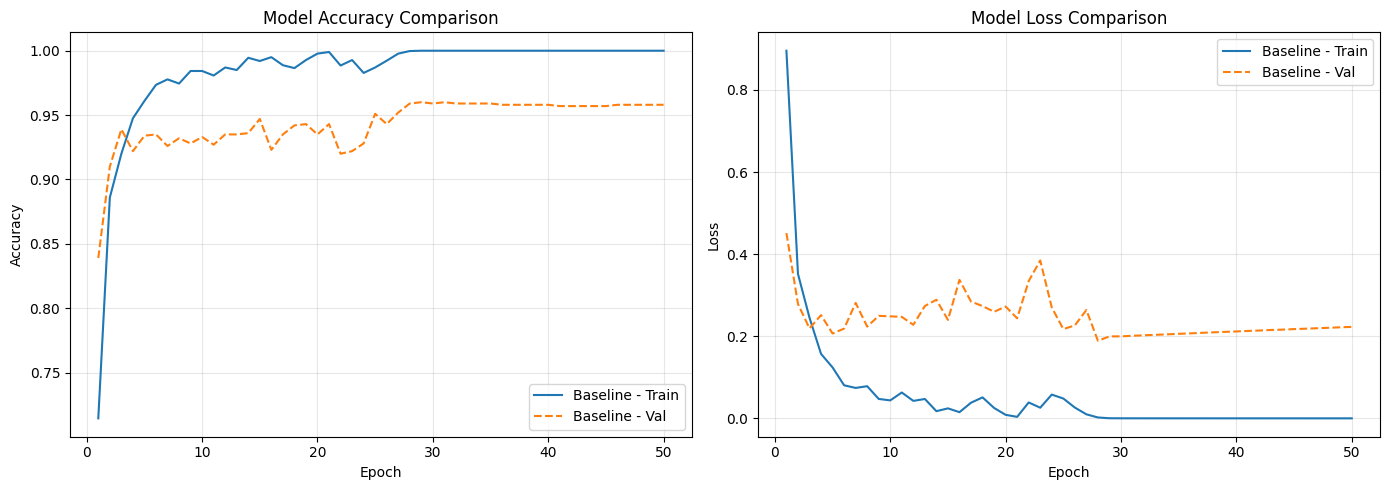

In [6]:
# Plot baseline results - notice the overfitting (gap between train and val)
plot_training_history([baseline_history], ['Baseline'])

---
## 2. L2 Regularization (Weight Decay)

In PyTorch, L2 regularization is implemented through the `weight_decay` parameter in optimizers. This is mathematically equivalent to adding L2 penalty to the loss.

**Mathematical formulation:**
$$\text{Loss}_{L2} = \text{Loss}_{original} + \frac{\lambda}{2} \sum_{i} w_i^2$$

In [7]:
# Create and train L2 regularized model using weight_decay
print("Training L2 Regularized Model (weight_decay)...")
l2_model = BaselineModel().to(device)
criterion = nn.CrossEntropyLoss()

# weight_decay parameter implements L2 regularization
optimizer_l2 = optim.Adam(l2_model.parameters(), lr=0.001, weight_decay=0.01)

l2_history = train_model(
    l2_model, train_loader, val_loader,
    optimizer_l2, criterion, device, epochs=50
)

Training L2 Regularized Model (weight_decay)...
Epoch 10/50 - Train Loss: 0.1641, Train Acc: 0.9477, Val Loss: 0.2390, Val Acc: 0.9270
Epoch 20/50 - Train Loss: 0.0973, Train Acc: 0.9745, Val Loss: 0.2615, Val Acc: 0.9150
Epoch 30/50 - Train Loss: 0.0841, Train Acc: 0.9765, Val Loss: 0.2564, Val Acc: 0.9160
Epoch 40/50 - Train Loss: 0.0618, Train Acc: 0.9865, Val Loss: 0.2558, Val Acc: 0.9250
Epoch 50/50 - Train Loss: 0.0784, Train Acc: 0.9812, Val Loss: 0.2208, Val Acc: 0.9260


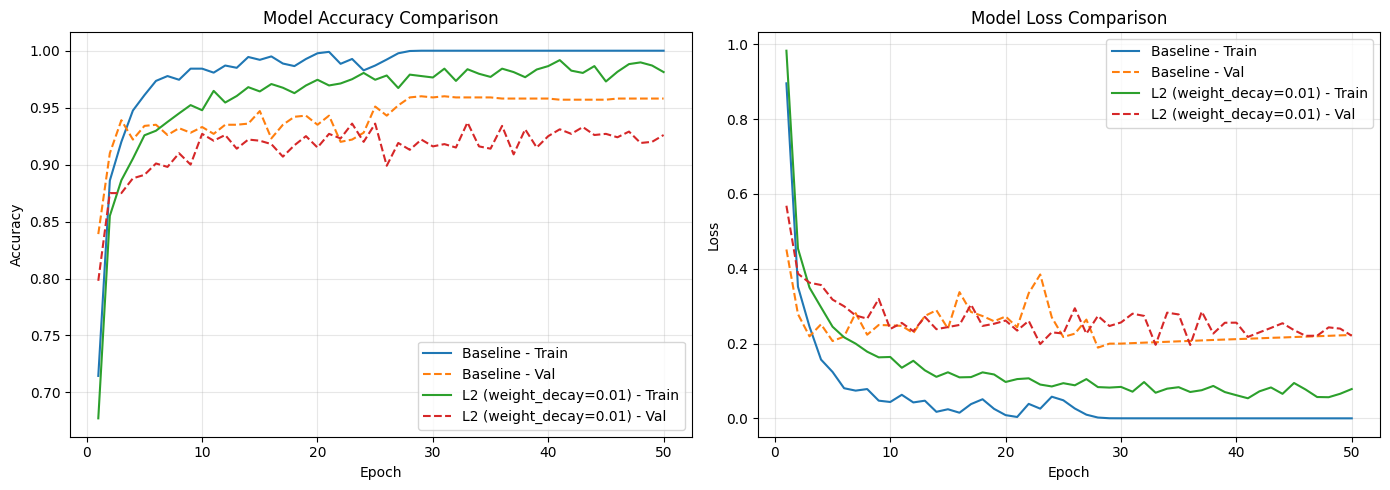

In [8]:
# Compare L2 with baseline
plot_training_history([baseline_history, l2_history], ['Baseline', 'L2 (weight_decay=0.01)'])

---
## 3. L1 Regularization

PyTorch doesn't have built-in L1 regularization in optimizers, so we add it manually to the loss function.

In [9]:
# Create and train L1 regularized model
print("Training L1 Regularized Model...")
l1_model = BaselineModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_l1 = optim.Adam(l1_model.parameters(), lr=0.001)

# Train with L1 regularization (l1_lambda parameter)
l1_history = train_model(
    l1_model, train_loader, val_loader,
    optimizer_l1, criterion, device,
    epochs=50, l1_lambda=0.0001  # L1 regularization strength
)

Training L1 Regularized Model...
Epoch 10/50 - Train Loss: 0.3854, Train Acc: 0.9785, Val Loss: 0.2119, Val Acc: 0.9340
Epoch 20/50 - Train Loss: 0.2674, Train Acc: 0.9888, Val Loss: 0.2174, Val Acc: 0.9310
Epoch 30/50 - Train Loss: 0.3335, Train Acc: 0.9660, Val Loss: 0.2731, Val Acc: 0.9190
Epoch 40/50 - Train Loss: 0.1207, Train Acc: 1.0000, Val Loss: 0.1731, Val Acc: 0.9490
Epoch 50/50 - Train Loss: 0.1273, Train Acc: 1.0000, Val Loss: 0.1782, Val Acc: 0.9560


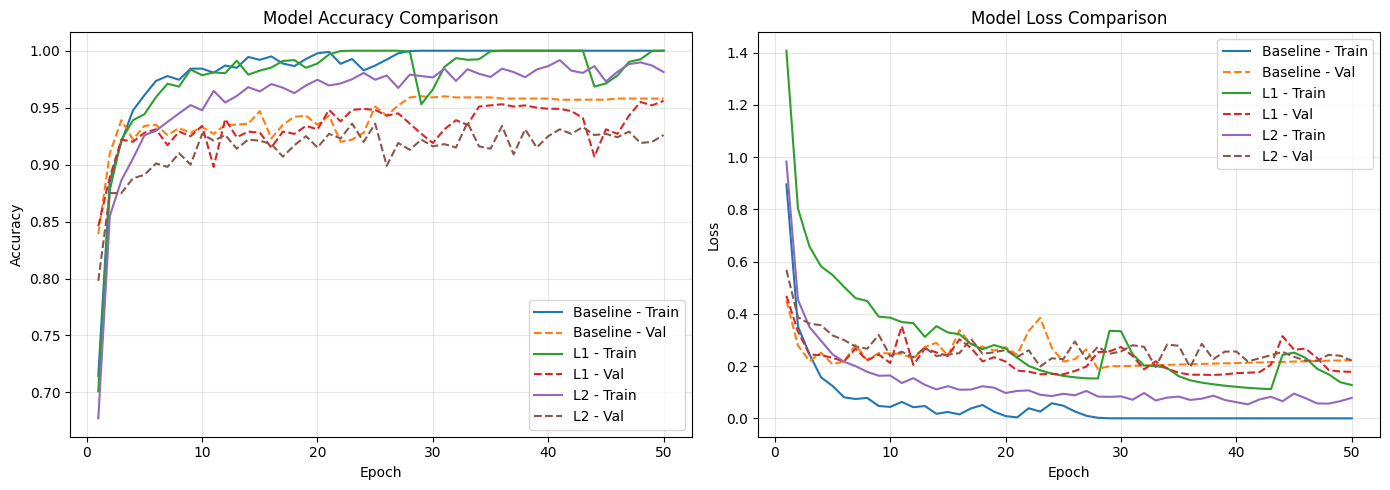

In [10]:
# Compare all regularization techniques
plot_training_history(
    [baseline_history, l1_history, l2_history],
    ['Baseline', 'L1', 'L2']
)

In [11]:
# Analyze L1 sparsity
print("Analyzing weight sparsity in L1 regularized model:")
for name, param in l1_model.named_parameters():
    if 'weight' in name:
        weights = param.data.cpu().numpy()
        near_zero = np.sum(np.abs(weights) < 1e-4)
        total = weights.size
        sparsity = (near_zero / total) * 100
        print(f"{name}: {sparsity:.2f}% weights near zero")

Analyzing weight sparsity in L1 regularized model:
fc1.weight: 77.07% weights near zero
fc2.weight: 75.63% weights near zero
fc3.weight: 72.92% weights near zero
fc4.weight: 69.78% weights near zero
fc5.weight: 24.30% weights near zero


---
## 4. Dropout Regularization

Dropout randomly sets neurons to zero during training. In PyTorch, we use `nn.Dropout` layers and must call `model.train()` and `model.eval()` appropriately.

In [12]:
class DropoutModel(nn.Module):
    """
    Neural network with Dropout layers for regularization.
    """
    def __init__(self, dropout_rate=0.5):
        super(DropoutModel, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, 256)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(128, 128)
        self.dropout4 = nn.Dropout(dropout_rate)
        self.fc5 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.dropout3(x)
        x = F.relu(self.fc4(x))
        x = self.dropout4(x)
        x = self.fc5(x)
        return x

# Create and train Dropout model
print("Training Dropout Model (rate=0.3)...")
dropout_model = DropoutModel(dropout_rate=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_dropout = optim.Adam(dropout_model.parameters(), lr=0.001)

dropout_history = train_model(
    dropout_model, train_loader, val_loader,
    optimizer_dropout, criterion, device, epochs=50
)

Training Dropout Model (rate=0.3)...
Epoch 10/50 - Train Loss: 0.1359, Train Acc: 0.9600, Val Loss: 0.2259, Val Acc: 0.9340
Epoch 20/50 - Train Loss: 0.0964, Train Acc: 0.9720, Val Loss: 0.2051, Val Acc: 0.9480
Epoch 30/50 - Train Loss: 0.0646, Train Acc: 0.9828, Val Loss: 0.2314, Val Acc: 0.9480
Epoch 40/50 - Train Loss: 0.0562, Train Acc: 0.9865, Val Loss: 0.2646, Val Acc: 0.9430
Epoch 50/50 - Train Loss: 0.0493, Train Acc: 0.9862, Val Loss: 0.2410, Val Acc: 0.9540


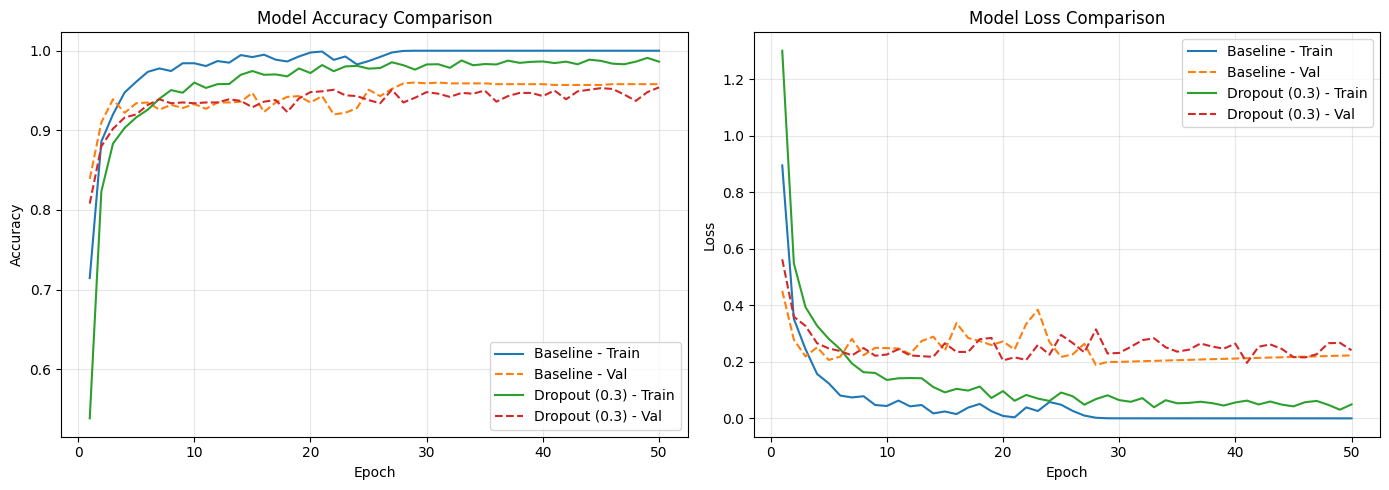

In [13]:
# Compare Dropout with baseline
plot_training_history(
    [baseline_history, dropout_history],
    ['Baseline', 'Dropout (0.3)']
)


A/B Testing Different Dropout Rates...

Training with dropout rate = 0.2
Epoch 10/30 - Train Loss: 0.1022, Train Acc: 0.9665, Val Loss: 0.2787, Val Acc: 0.9310
Epoch 20/30 - Train Loss: 0.0700, Train Acc: 0.9798, Val Loss: 0.2894, Val Acc: 0.9320
Epoch 30/30 - Train Loss: 0.0547, Train Acc: 0.9858, Val Loss: 0.2141, Val Acc: 0.9560

Training with dropout rate = 0.3
Epoch 10/30 - Train Loss: 0.1382, Train Acc: 0.9593, Val Loss: 0.2107, Val Acc: 0.9440
Epoch 20/30 - Train Loss: 0.0776, Train Acc: 0.9800, Val Loss: 0.2620, Val Acc: 0.9470
Epoch 30/30 - Train Loss: 0.0562, Train Acc: 0.9825, Val Loss: 0.2325, Val Acc: 0.9480

Training with dropout rate = 0.5
Epoch 10/30 - Train Loss: 0.3448, Train Acc: 0.9035, Val Loss: 0.2493, Val Acc: 0.9170
Epoch 20/30 - Train Loss: 0.2235, Train Acc: 0.9383, Val Loss: 0.2187, Val Acc: 0.9470
Epoch 30/30 - Train Loss: 0.2061, Train Acc: 0.9453, Val Loss: 0.2261, Val Acc: 0.9380


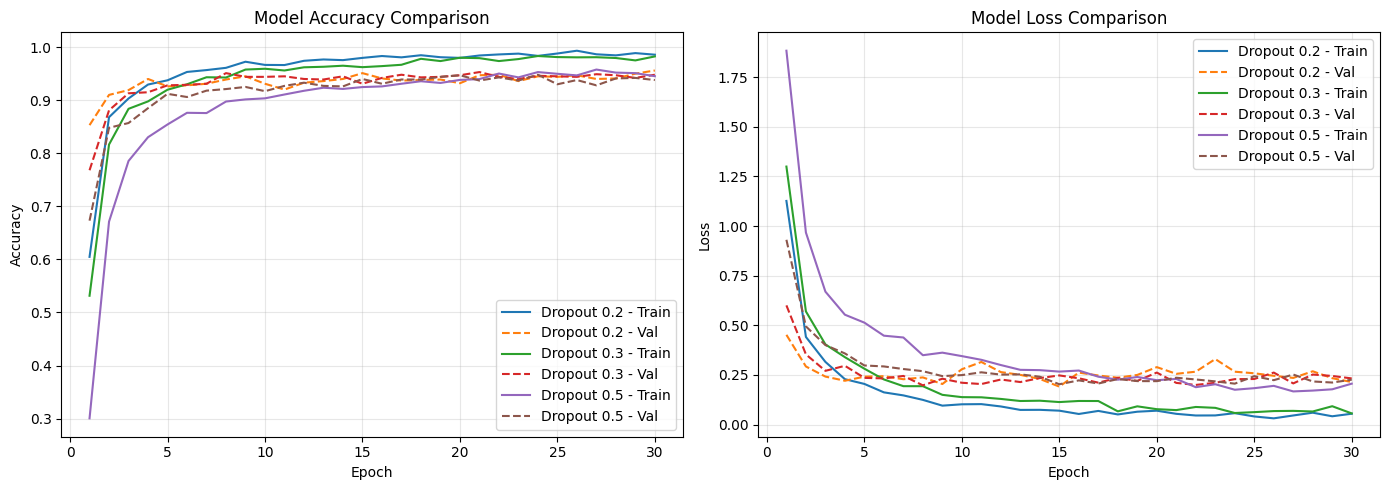

In [14]:
# A/B Test: Compare different dropout rates
print("\nA/B Testing Different Dropout Rates...")

dropout_rates = [0.2, 0.3, 0.5]
dropout_histories = []
dropout_labels = []

for rate in dropout_rates:
    print(f"\nTraining with dropout rate = {rate}")
    model = DropoutModel(dropout_rate=rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = train_model(
        model, train_loader, val_loader,
        optimizer, criterion, device, epochs=30
    )
    dropout_histories.append(history)
    dropout_labels.append(f'Dropout {rate}')

# Plot comparison
plot_training_history(dropout_histories, dropout_labels)

---
## 5. Early Stopping

Early stopping monitors validation loss and stops training when it stops improving.

In [15]:
# Implement Early Stopping class for reusability
class EarlyStopping:
    """
    Early stopping utility to stop training when validation loss stops improving.
    """
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def restore_best_weights(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


# Train with early stopping
print("Training with Early Stopping (patience=5)...")
early_stop_model = BaselineModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_es = optim.Adam(early_stop_model.parameters(), lr=0.001)

early_stop_history = train_model(
    early_stop_model, train_loader, val_loader,
    optimizer_es, criterion, device,
    epochs=100, early_stopping=True, patience=5
)

print(f"\nTraining stopped at epoch {len(early_stop_history['train_loss'])}")

Training with Early Stopping (patience=5)...
Epoch 10/100 - Train Loss: 0.0502, Train Acc: 0.9828, Val Loss: 0.2026, Val Acc: 0.9400
Early stopping at epoch 15

Training stopped at epoch 15


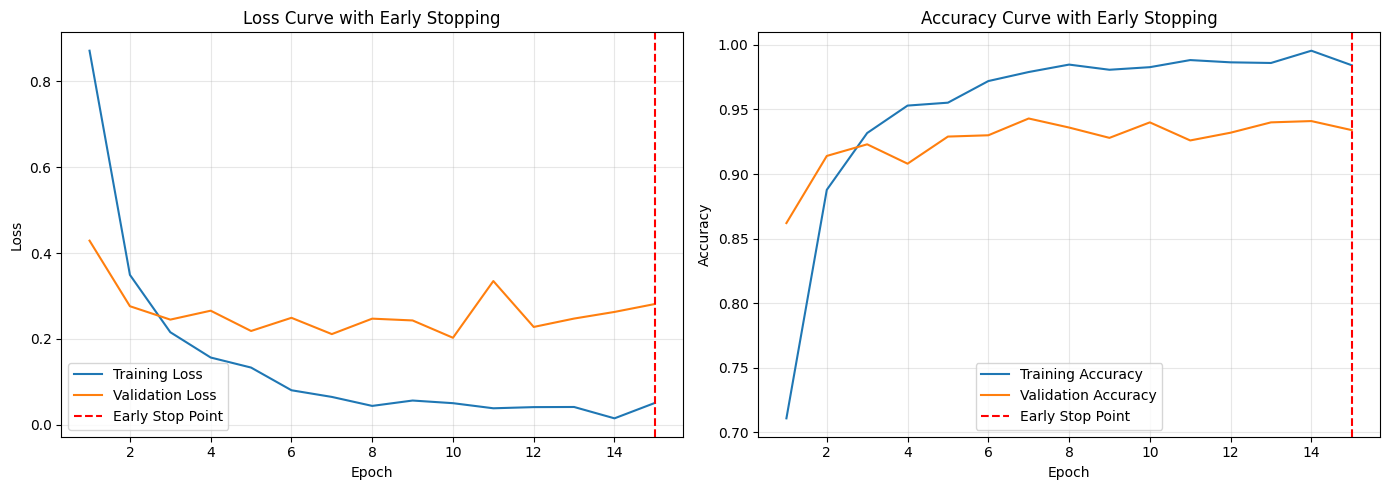

In [16]:
# Plot early stopping results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(early_stop_history['train_loss']) + 1)

axes[0].plot(epochs, early_stop_history['train_loss'], label='Training Loss')
axes[0].plot(epochs, early_stop_history['val_loss'], label='Validation Loss')
axes[0].axvline(x=len(epochs), color='r', linestyle='--', label='Early Stop Point')
axes[0].set_title('Loss Curve with Early Stopping')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, early_stop_history['train_acc'], label='Training Accuracy')
axes[1].plot(epochs, early_stop_history['val_acc'], label='Validation Accuracy')
axes[1].axvline(x=len(epochs), color='r', linestyle='--', label='Early Stop Point')
axes[1].set_title('Accuracy Curve with Early Stopping')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Batch Normalization

Batch Normalization normalizes layer inputs. In PyTorch, we use `nn.BatchNorm1d` for fully connected layers.

In [17]:
class BatchNormModel(nn.Module):
    """
    Neural network with Batch Normalization layers.
    BatchNorm is placed BEFORE activation in modern practice.
    """
    def __init__(self):
        super(BatchNormModel, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 128)
        self.bn4 = nn.BatchNorm1d(128)

        self.fc5 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.fc5(x)
        return x

# Create and train BatchNorm model
print("Training Batch Normalization Model...")
batchnorm_model = BatchNormModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_bn = optim.Adam(batchnorm_model.parameters(), lr=0.001)

batchnorm_history = train_model(
    batchnorm_model, train_loader, val_loader,
    optimizer_bn, criterion, device, epochs=50
)

Training Batch Normalization Model...
Epoch 10/50 - Train Loss: 0.0486, Train Acc: 0.9848, Val Loss: 0.1748, Val Acc: 0.9470
Epoch 20/50 - Train Loss: 0.0256, Train Acc: 0.9910, Val Loss: 0.2311, Val Acc: 0.9330
Epoch 30/50 - Train Loss: 0.0268, Train Acc: 0.9920, Val Loss: 0.1991, Val Acc: 0.9500
Epoch 40/50 - Train Loss: 0.0182, Train Acc: 0.9948, Val Loss: 0.2206, Val Acc: 0.9550
Epoch 50/50 - Train Loss: 0.0220, Train Acc: 0.9920, Val Loss: 0.1972, Val Acc: 0.9460


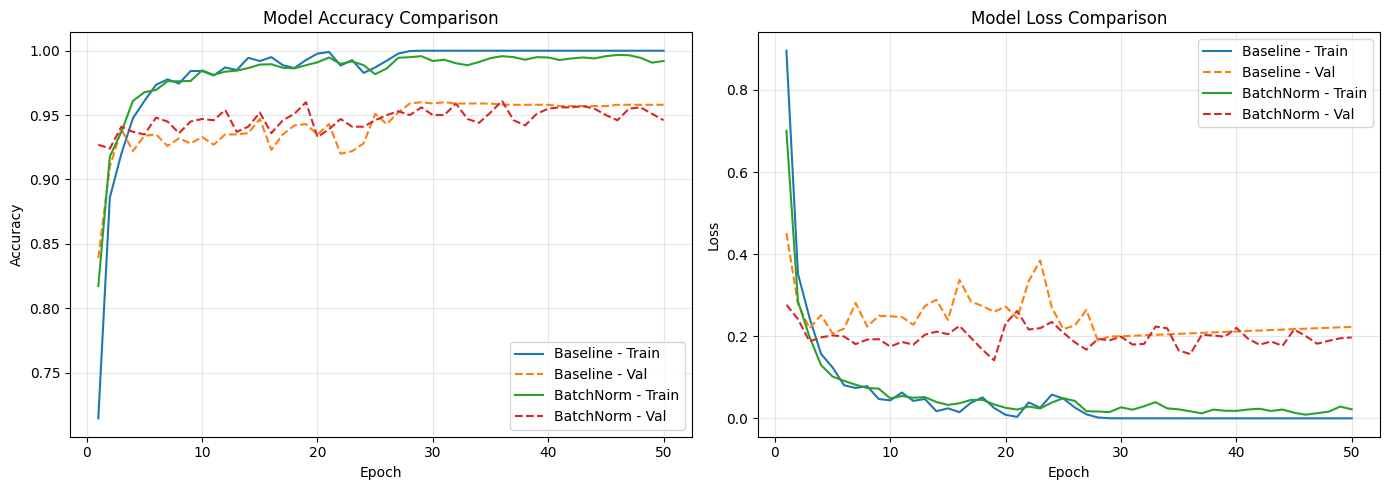

In [18]:
# Compare BatchNorm with baseline
plot_training_history(
    [baseline_history, batchnorm_history],
    ['Baseline', 'BatchNorm']
)

---
## 7. Combined Regularization

In [19]:
class FullyRegularizedModel(nn.Module):
    """
    Model combining multiple regularization techniques:
    - Batch Normalization
    - Dropout
    (L2 is added via weight_decay in optimizer)
    """
    def __init__(self, dropout_rate=0.3):
        super(FullyRegularizedModel, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(dropout_rate)

        self.fc4 = nn.Linear(128, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(dropout_rate)

        self.fc5 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.dropout1(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(F.relu(self.bn3(self.fc3(x))))
        x = self.dropout4(F.relu(self.bn4(self.fc4(x))))
        x = self.fc5(x)
        return x

# Create and train fully regularized model
print("Training Fully Regularized Model (BatchNorm + Dropout + L2 + Early Stopping)...")
full_reg_model = FullyRegularizedModel(dropout_rate=0.3).to(device)
criterion = nn.CrossEntropyLoss()

# L2 regularization via weight_decay
optimizer_full = optim.Adam(full_reg_model.parameters(), lr=0.001, weight_decay=0.001)

full_reg_history = train_model(
    full_reg_model, train_loader, val_loader,
    optimizer_full, criterion, device,
    epochs=100, early_stopping=True, patience=10
)

Training Fully Regularized Model (BatchNorm + Dropout + L2 + Early Stopping)...
Epoch 10/100 - Train Loss: 0.2121, Train Acc: 0.9387, Val Loss: 0.1979, Val Acc: 0.9400
Epoch 20/100 - Train Loss: 0.1326, Train Acc: 0.9557, Val Loss: 0.1600, Val Acc: 0.9540
Epoch 30/100 - Train Loss: 0.1263, Train Acc: 0.9607, Val Loss: 0.1557, Val Acc: 0.9570
Early stopping at epoch 39


---
## 8. Final Comparison: A/B Test Results

In [20]:
# Evaluate all models on test set
print("="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

models_to_evaluate = [
    (baseline_model, "Baseline (No Regularization)"),
    (l1_model, "L1 Regularization"),
    (l2_model, "L2 Regularization (weight_decay)"),
    (dropout_model, "Dropout (0.3)"),
    (early_stop_model, "Early Stopping"),
    (batchnorm_model, "Batch Normalization"),
    (full_reg_model, "Combined Regularization")
]

results = []
criterion = nn.CrossEntropyLoss()

for model, name in models_to_evaluate:
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"{name}: Test Loss = {test_loss:.4f}, Test Accuracy = {test_acc:.4f}")
    results.append((name, test_loss, test_acc))

print("\n" + "="*60)

FINAL TEST SET EVALUATION
Baseline (No Regularization): Test Loss = 0.3288, Test Accuracy = 0.9540
L1 Regularization: Test Loss = 0.2333, Test Accuracy = 0.9459
L2 Regularization (weight_decay): Test Loss = 0.2224, Test Accuracy = 0.9321
Dropout (0.3): Test Loss = 0.3324, Test Accuracy = 0.9479
Early Stopping: Test Loss = 0.2488, Test Accuracy = 0.9402
Batch Normalization: Test Loss = 0.2192, Test Accuracy = 0.9496
Combined Regularization: Test Loss = 0.1720, Test Accuracy = 0.9507



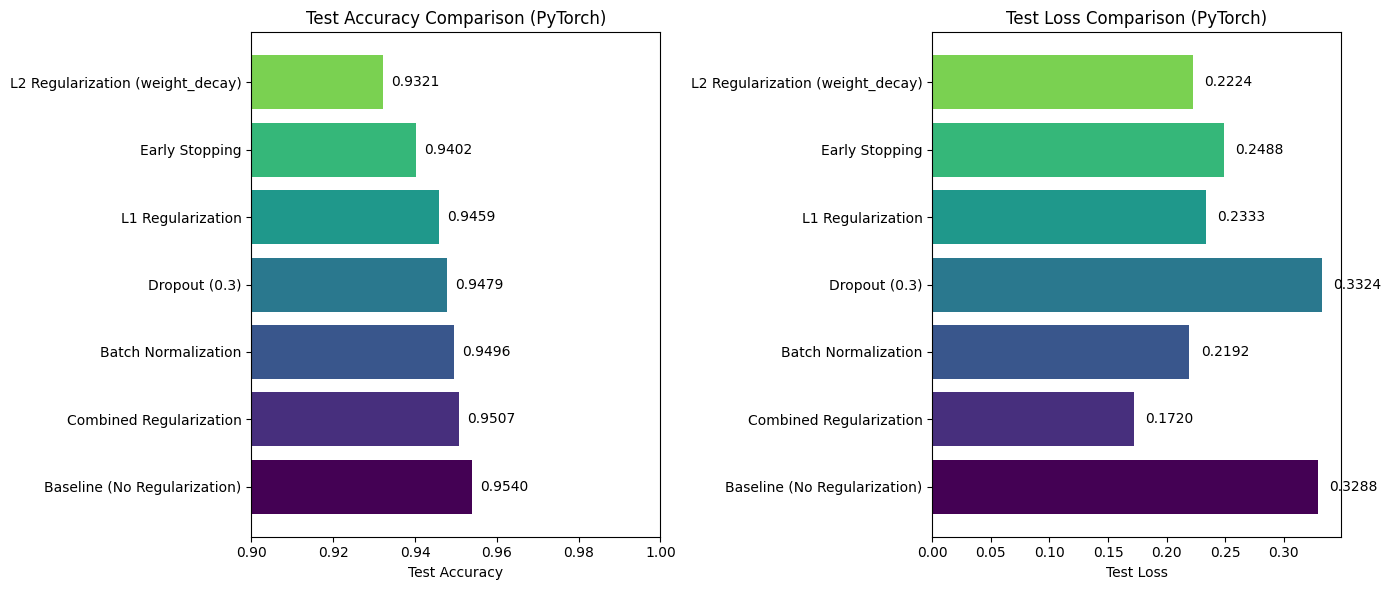


Results Table:
                           Model  Test Loss  Test Accuracy
    Baseline (No Regularization)   0.328832         0.9540
         Combined Regularization   0.171977         0.9507
             Batch Normalization   0.219200         0.9496
                   Dropout (0.3)   0.332423         0.9479
               L1 Regularization   0.233310         0.9459
                  Early Stopping   0.248770         0.9402
L2 Regularization (weight_decay)   0.222365         0.9321


In [21]:
# Visualize comparison
import pandas as pd

results_df = pd.DataFrame(results, columns=['Model', 'Test Loss', 'Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 0.8, len(results_df)))

# Accuracy comparison
bars1 = axes[0].barh(results_df['Model'], results_df['Test Accuracy'], color=colors)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy Comparison (PyTorch)')
axes[0].set_xlim(0.9, 1.0)
for bar, acc in zip(bars1, results_df['Test Accuracy']):
    axes[0].text(acc + 0.002, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', va='center', fontsize=10)

# Loss comparison
bars2 = axes[1].barh(results_df['Model'], results_df['Test Loss'], color=colors)
axes[1].set_xlabel('Test Loss')
axes[1].set_title('Test Loss Comparison (PyTorch)')
for bar, loss in zip(bars2, results_df['Test Loss']):
    axes[1].text(loss + 0.01, bar.get_y() + bar.get_height()/2,
                f'{loss:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nResults Table:")
print(results_df.to_string(index=False))

---
## Summary

### PyTorch Regularization Key Points:

| Technique | PyTorch Implementation | Notes |
|-----------|----------------------|-------|
| **L1** | Manual addition to loss | `torch.norm(param, 1)` |
| **L2** | `weight_decay` in optimizer | Most common approach |
| **Dropout** | `nn.Dropout(p)` | Must use `.train()` and `.eval()` |
| **BatchNorm** | `nn.BatchNorm1d(features)` | Different behavior in train/eval |
| **Early Stopping** | Custom implementation | Save best model state |

### Best Practices in PyTorch:
1. Always call `model.train()` before training and `model.eval()` before evaluation
2. Use `weight_decay` for L2 regularization (simpler than manual)
3. Save model state dict for early stopping: `torch.save(model.state_dict(), path)`
4. Combine techniques for best results